# Modelo con aumento de datos

Este notebook implementa una **red neuronal convolucional (CNN)** mejorada que incorpora **aumento de datos (data augmentation)** para mejorar el rendimiento en la clasificación de imágenes del juego "Piedra, Papel o Tijera".

Las principales actividades son:

- Carga de datos preprocesados (`X_hand.npy`, `y_hand.npy`) y su división en entrenamiento y validación.
- Normalización de imágenes y codificación one-hot de las etiquetas.
- Definición de un generador de datos (`ImageDataGenerator`) con transformaciones como:
  - Rotación
  - Desplazamiento horizontal y vertical
  - Zoom
  - Flip horizontal
- Construcción de un modelo CNN más profundo que incluye:
  - Tres capas `Conv2D` + `MaxPooling2D`
  - Capa `Flatten` y dos capas `Dense` para clasificación
- Entrenamiento del modelo con los datos aumentados y evaluación sobre el conjunto de validación.
- Visualización del desempeño del modelo (precisión y pérdida por época).
- Guardado del modelo entrenado (`modelo_CNN_Aug.keras`).

>  El uso de aumento de datos contribuye a reducir el sobreajuste y mejorar la generalización del modelo en nuevos datos.  Se sugiere mejorar su arquitectura como ejercicio adicional.



In [1]:
!ls dataset

ls: cannot access 'dataset': No such file or directory


In [7]:
from numpy import load

X = load('X_hand_SM.npy')
y = load('y_hand_SM.npy')

In [8]:
len(X)

1652

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
X_train.shape

(1239, 64, 64, 3)

In [10]:
X_train_scaled  = X_train / 255
X_test_scaled  = X_test / 255

In [11]:
# one hot encode outputs
from tensorflow.keras.utils import to_categorical

y_train = to_categorical( y_train )
y_test = to_categorical( y_test )

In [12]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
#from keras.layers.convolutional import Conv2D
#from keras.layers.convolutional import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  Aumento de datos SOLO para entrenamiento
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# No se hace nada en validacion
test_datagen = ImageDataGenerator()

#  Generadores desde arrays numpy
# train_generator Entrega imágenes aumentadas (rotadas, desplazadas, etc.) para entrenamiento.
train_generator = train_datagen.flow(X_train_scaled, y_train, batch_size=32)
# val_generator Entrega imágenes sin alterar (solo normalizadas) para validación o prueba.
val_generator = test_datagen.flow(X_test_scaled, y_test, batch_size=32)


#https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/
#https://faroit.com/keras-docs/1.2.2/preprocessing/image/
#https://towardsdatascience.com/exploring-image-data-augmentation-with-keras-and-tensorflow-a8162d89b844

Modelo

1. Conv 16 (3,3) , relu
2. MP (2,2)
3. Conv 32 (3,3) , relu  
4. MP (2,2)
5. Flatten
6. 128 , relu
7. num_classes, softmax

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

def modelo_CNN_Aug():
    model = Sequential()
    model.add(  Input( shape= (64,64,3)  )   )
    model.add(  Conv2D ( 16, (3,3) , activation='relu' )          )
    model.add(  MaxPooling2D(2,2) )
    model.add(  Dropout(0.2)  )
    model.add(  Flatten() )
    model.add(  Dense( 128, activation='relu'  ) )
    model.add(  Dense( 3, activation='softmax'     ) )
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])  
    return model

In [15]:
#  Creamos y entrenamos el modelo
model = modelo_CNN_Aug()
history_CNN_Aug = model.fit(train_generator, validation_data=val_generator, epochs=100)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.3785 - loss: 1.6397 - val_accuracy: 0.5496 - val_loss: 0.9654
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5004 - loss: 0.9836 - val_accuracy: 0.5666 - val_loss: 0.9187
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5545 - loss: 0.9404 - val_accuracy: 0.5327 - val_loss: 0.9390
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5593 - loss: 0.9076 - val_accuracy: 0.5932 - val_loss: 0.8532
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5771 - loss: 0.8923 - val_accuracy: 0.6295 - val_loss: 0.8476
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6037 - loss: 0.8442 - val_accuracy: 0.6852 - val_loss: 0.7454
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6247 - loss: 0.8108 - val_accuracy: 0.6344 - val_loss: 0.7850
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6425 - loss: 0.7923 - val_accuracy: 0

In [16]:
# Final evaluation of the model
scores=model.evaluate(X_test_scaled,y_test,verbose=0)

print('Error del modelo base : %.2f%%' % (100-scores[1]*100))

Error del modelo base : 10.17%


(0.0, 2.0)

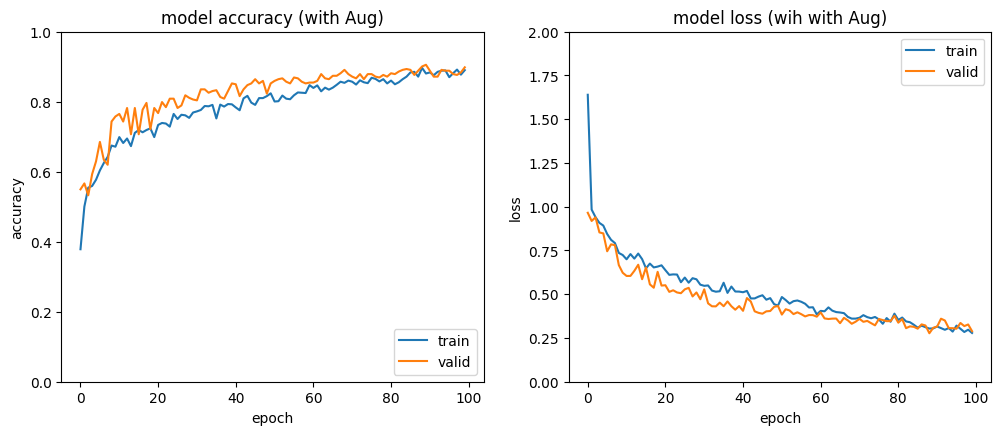

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(history_CNN_Aug.history['accuracy'])
plt.plot(history_CNN_Aug.history['val_accuracy'])
plt.ylim(0, 1)
plt.title('model accuracy (with Aug)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='lower right')
plt.subplot(2,2,2)
plt.plot(history_CNN_Aug.history['loss'])
plt.plot(history_CNN_Aug.history['val_loss'])
plt.title('model loss (wih with Aug)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper right')
plt.ylim([0,2])

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


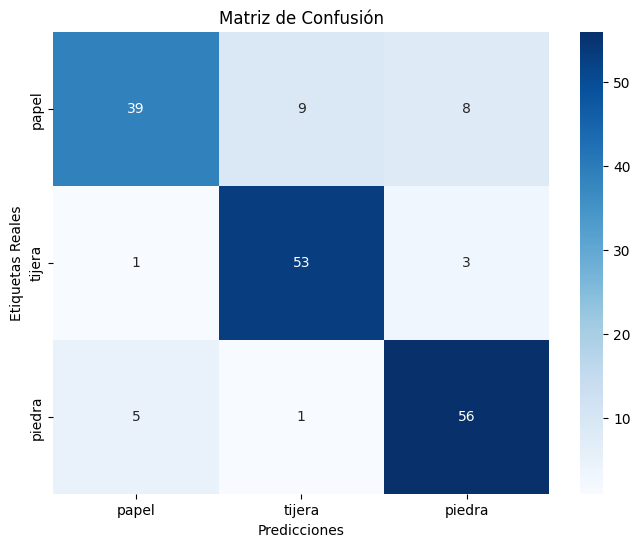

In [22]:
X_test = np.load('X_hand_test.npy')
y_test = np.load('y_hand_test.npy')

import tensorflow as tf
X_test= tf.image.resize(X_test, (64, 64))

# Escalar los datos
X_test_scaled = X_test / 255

#  Predicciones sobre los datos de test
y_pred = model.predict(X_test_scaled)

# Convertir las predicciones (one-hot) a etiquetas de clase
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test # Assuming y_test_oct is already in class labels

# Convertir los índices a las etiquetas correspondientes usando el diccionario
labels_dict = {'papel': 0, 'tijera': 1, 'piedra': 2}
labels = list(labels_dict.keys())

#  Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Reales')
plt.show()

In [12]:
model.save('modelo_CNN_Aug.keras')

# Segundo Modelo (TAREA)
Encontrar un nuevo modelo que sea mejor